In [1]:
import os
os.chdir('/workspace/1b083659-a027-40c3-bf25-44b8a3bd6bf3')
print(os.listdir('.'))


['F2_t.npy', 'F2_real.npy', 'rho0.npy', 'F5p_imag.npy', 'memory', 'F1_t.npy', '.kernel_llm_logs_1.txt', 'N.npy', 'F7_real.npy', 'F7_imag.npy', 'F1_real.npy', 'F6_t.npy', ' v6 — Binding Context Document.pdf', 'description.npy', 'lambda_n.npy', 'hypothesis_AUC_results.json', 'F5p_real.npy', 'F1_imag.npy', 'F6_imag.npy', '.config', 'F5p_t.npy', 'a_n.npy', 'F4_t.npy', 'c.npy', 'F2_imag.npy', 'F4_real.npy', 'a.npy', 'F5m_real.npy', 'F6_real.npy', 'F5m_imag.npy', 'F5m_t.npy', 'F4_imag.npy', '.prompts', 'peaks_features_F1_F12_normalized_full.csv', 'F7_t.npy']


In [2]:
import numpy as np, pandas as pd
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [3]:
print(df['function'].value_counts())
print('GRH:', df.groupby('function')['GRH'].first().to_dict())


function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
GRH: {'F1': True, 'F10': True, 'F11': True, 'F12': False, 'F2': True, 'F4': False, 'F5m': False, 'F5p': False, 'F6': True, 'F7': True, 'F9': True}


In [4]:
# Check the existing complex Sk arrays
for f in ['F1','F2','F4','F5p','F5m','F6','F7']:
 real = np.load(f'{f}_real.npy')
 imag = np.load(f'{f}_imag.npy')
 t = np.load(f'{f}_t.npy')
 print(f, real.shape, imag.shape, t.shape, real.dtype)
print('N=', np.load('N.npy'))


F1 (200, 8) (200, 8) (200,) float64
F2 (200, 8) (200, 8) (200,) float64
F4 (200, 8) (200, 8) (200,) float64
F5p (200, 8) (200, 8) (200,) float64
F5m (200, 8) (200, 8) (200,) float64
F6 (200, 8) (200, 8) (200,) float64
F7 (200, 8) (200, 8) (200,) float64
N= 1000000


In [5]:
# Need coefficient files for F9, F10, F11, F12. Check what's locally available
print('a_n:', np.load('a_n.npy', allow_pickle=True).shape, np.load('a_n.npy', allow_pickle=True).dtype)
print('lambda_n:', np.load('lambda_n.npy', allow_pickle=True).shape, np.load('lambda_n.npy', allow_pickle=True).dtype)
print('a:', np.load('a.npy', allow_pickle=True).shape, np.load('a.npy', allow_pickle=True).dtype)
print('c:', np.load('c.npy', allow_pickle=True))
print('rho0:', np.load('rho0.npy', allow_pickle=True))
print('description:', np.load('description.npy', allow_pickle=True))


a_n: (1000000,) object
lambda_n: (1000000,) float64
a: (1000000,) complex128
c: (-0.16567330026345564+1.9009252335917202j)
rho0: (0.7+7j)
description: F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.


In [6]:
# Looks like 'a_n', 'lambda_n' likely belong to one class (maybe F9 or F10), 'a', 'c', 'rho0', 'description' are F12.
# We need F9, F10, F11 individually. Let me check what's there.
import os
# look for hints
print('a_n[:5]:', np.load('a_n.npy', allow_pickle=True)[:5])
print('lambda_n[:5]:', np.load('lambda_n.npy', allow_pickle=True)[:5])
# tau(1)=1, tau(2)=-24, tau(3)=252, tau(4)=-1472, tau(5)=4830 → F9 Ramanujan Delta


a_n[:5]: [1 -1472 -113643 5181440 -25499225]
lambda_n[:5]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]


In [7]:
# a_n[1] = -1472 doesn't match tau(2) = -24. But -1472 = tau(4). So this is offset 0-indexed where a_n[0]=1=tau(1), a_n[1]=-1472=tau(4)? No.
# Actually let me think: a_n[0]=1, a_n[1]=-1472, a_n[2]=-113643, a_n[3]=5181440, a_n[4]=-25499225
# tau(1)=1, tau(2)=-24, tau(3)=252, tau(4)=-1472, tau(5)=4830, tau(6)=-6048, tau(7)=-16744, tau(8)=84480, tau(9)=-113643
# So a_n[0]=tau(1), a_n[1]=tau(4)=-1472, a_n[2]=tau(9)=-113643? = those are tau(n^2)? a_n[3]=tau(16)=tau(2^4)
# tau(16) by recurrence: tau(p^(k+1))=tau(p)tau(p^k)-p^11 tau(p^(k-1)). 
# Actually 5181440... let's check what L-function. b_p = tau(p)^2 - p^11 -- this is F11 Sym^2(Delta)!
# tau(2)^2 - 2^11 = 576 - 2048 = -1472. Yes! a_n[1] = b_2 = -1472. So 'a_n' is F11 Sym^2(Delta).
# So we have F11 (a_n, lambda_n) and F12 (a). Missing F9, F10.
print("Detected: a_n.npy = F11 Sym^2(Delta) coefficients")


Detected: a_n.npy = F11 Sym^2(Delta) coefficients


In [8]:
# a_n.npy is F11 (Sym^2 Delta), confirmed by tau(2)^2 - 2^11 = -1472. F9 (Delta) and F10 (11.2.a.a) are missing.
# We need to generate F9 (Ramanujan tau) and F10 (11.2.a.a) coefficients up to N=10^6.

# Check cypari2 availability
try:
 import cypari2
 print('cypari2 ok', cypari2.__version__ if hasattr(cypari2,'__version__') else 'imported')
except Exception as e:
 print('cypari2 missing:', e)


cypari2 missing: No module named 'cypari2'


In [9]:
import subprocess
r = subprocess.run(['pip','install','cypari2','-q'], capture_output=True, text=True, timeout=300)
print('STDOUT:', r.stdout[-500:])
print('STDERR:', r.stderr[-1000:])


STDOUT: 
STDERR: 


In [10]:
import cypari2
pari = cypari2.Pari()
pari.allocatemem(4*1024**3) # 4 GB stack
print('PARI ready')


PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
PARI ready


In [11]:
import time, numpy as np
N = 1_000_000

# F9: Ramanujan Delta = 1.12.a.a (level 1, weight 12)
t0 = time.time()
mf9 = pari('mfinit([1,12],0)')
F9_form = pari('mfeigenbasis(mfinit([1,12],0))[1]')
# Use mfcoefs
coefs9 = pari(f'mfcoefs(mfeigenbasis(mfinit([1,12],0))[1], {N})')
print('F9 coefs computed in', time.time()-t0,'s, len=', len(coefs9))
# coefs9 is a vector with index 0..N (PARI returns vector of length N+1, with c[0]=0 typically? let's check)
print('first 6:', [int(coefs9[i]) for i in range(6)])


F9 coefs computed in 257.6384460926056 s, len= 1000001
first 6: [0, 1, -24, 252, -1472, 4830]


In [12]:
# Convert to int64 (tau(n) for n up to 10^6 fits in int64? tau(n) ~ O(n^(11/2 + eps)). At n=10^6, n^(11/2)=10^33.
# That overflows int64. Need object array (Python int).
import time
t0 = time.time()
F9_a = np.empty(N, dtype=object)
for i in range(1, N+1):
 F9_a[i-1] = int(coefs9[i])
print('Converted in', time.time()-t0,'s')
# Normalized lambda_n = a_n / n^(11/2)
F9_lambda = np.array([float(F9_a[i-1])/(i**5.5) for i in range(1,N+1)])
print('F9 lambda computed, sample:', F9_lambda[:5])
np.save('coeffs_F9_a.npy', F9_a)
np.save('coeffs_F9_lambda.npy', F9_lambda)
print('Saved F9')


Converted in 1.2205607891082764 s


F9 lambda computed, sample: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]
Saved F9


In [13]:
# For F9, conversion to float for n^(11/2) uses int->float. For n=10^6, int 10^6**5.5 = 10^33 which is fine for float (no overflow, just precision loss). And |tau(n)|/n^(11/2) is bounded. Good.

# F10: level 11 weight 2, newform 11.2.a.a
t0 = time.time()
coefs10 = pari(f'mfcoefs(mfeigenbasis(mfinit([11,2],0))[1], {N})')
print('F10 coefs computed in', time.time()-t0,'s, len=', len(coefs10))
print('first 8:', [int(coefs10[i]) for i in range(8)])
# 11.2.a.a: a_1=1, a_2=-2, a_3=-1, a_4=2, a_5=1, a_6=2, a_7=-2, a_8=0...


F10 coefs computed in 194.03005862236023 s, len= 1000001
first 8: [0, 1, -2, -1, 2, 1, 2, -2]


In [14]:
# Good - matches 11.2.a.a. Coefficients for weight 2 are bounded by Deligne: |a_p| <= 2*sqrt(p), so |a_n| <= n^(1/2)*d(n). For N=10^6 fits int64 easily.
F10_a = np.array([int(coefs10[i]) for i in range(1, N+1)], dtype=np.int64)
F10_lambda = F10_a.astype(np.float64) / np.sqrt(np.arange(1, N+1, dtype=np.float64))
print('F10 first 5 a_n:', F10_a[:5], 'lambda:', F10_lambda[:5])
np.save('coeffs_F10_a.npy', F10_a)
np.save('coeffs_F10_lambda.npy', F10_lambda)
print('Saved F10')


F10 first 5 a_n: [ 1 -2 -1 2 1] lambda: [ 1. -1.41421356 -0.57735027 1. 0.4472136 ]
Saved F10


In [15]:
# F11 already in a_n.npy as Sym^2(Delta). Verify.
F11_a_obj = np.load('a_n.npy', allow_pickle=True)
F11_lambda = np.load('lambda_n.npy', allow_pickle=True)
print('F11 a_n[:5]:', F11_a_obj[:5])
print('F11 lambda[:5]:', F11_lambda[:5])
# F12 in a.npy
F12_a = np.load('a.npy', allow_pickle=True)
print('F12 first 5:', F12_a[:5])


F11 a_n[:5]: [1 -1472 -113643 5181440 -25499225]
F11 lambda[:5]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]
F12 first 5: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]


In [16]:
# Now build a Numba-accelerated complex Sk computation engine.
# Definition recap: Per the binding context, S_k(t; N) is the omega-stratified main sum: 
# S_k(t; N) = sum_{n<=N, omega(n)=k} lambda_n * n^(-1/2 - i t)
# where lambda_n is the analytic-normalized coefficient.
# It's "normalized" presumably so that S_0(t;N)=1 (since omega(1)=0 and lambda_1=1).
# Let's verify with F1 (zeta): lambda_n=1, sum over omega(n)=0 just = 1. yes S_0=1. 
F1r = np.load('F1_real.npy'); F1i = np.load('F1_imag.npy')
print('F1 S_0 sample real,imag (should be 1+0i):', F1r[0,0], F1i[0,0])
# All omega-stratified


F1 S_0 sample real,imag (should be 1+0i): 1.0 0.0


In [17]:
# Need omega(n) for n=1..N. Compute via sieve.
import numpy as np, time
N = 1_000_000

t0 = time.time()
omega = np.zeros(N+1, dtype=np.int8)
# Sieve: for each prime p, increment omega[multiples]
is_comp = np.zeros(N+1, dtype=bool)
for p in range(2, N+1):
 if not is_comp[p]:
 # p is prime
 omega[p::p] += 1
 # mark composites starting p*p
 if p*p <= N:
 is_comp[p*p::p] = True
print('Sieve done', time.time()-t0,'s')
print('omega[1..10]:', omega[1:11])
# omega(1)=0, 2=1, 3=1, 4=1, 5=1, 6=2, 7=1, 8=1, 9=1, 10=2 ✓
print('max omega:', omega[1:].max(), 'unique:', np.unique(omega[1:]))


Sieve done 0.21883583068847656 s
omega[1..10]: [0 1 1 1 1 2 1 1 1 2]
max omega: 7 unique: [0 1 2 3 4 5 6 7]


In [18]:
# Build a Numba kernel for complex S_k(t; N) computation with Kahan compensated summation.
# Input: lambda_n (complex128 array length N), omega array (int8 length N), n_arr 1..N, t value.
# Compute for each k=0..7: S_k = sum_{omega(n)=k} lambda_n * n^(-1/2 - i t)
# = sum lambda_n / sqrt(n) * exp(-i t log n)

# Precompute log(n)/sqrt(n) and lambda_n as float arrays. We'll do per-class.

# But N=10^6, 200 peaks, 11 classes. For each peak we need 8 sums over up to 10^6 terms.
# Total work: 11 * 200 * 10^6 = 2.2e9 operations. Numba with parallel will handle in minutes.

from numba import njit, prange
import math

@njit(cache=True, parallel=False, fastmath=False)
def compute_Sk_one(lam_re, lam_im, log_n, inv_sqrt_n, omega_arr, t):
 # Returns 8 complex values
 Sre = np.zeros(8); Sim = np.zeros(8)
 cre = np.zeros(8); cim = np.zeros(8) # Kahan compensation
 N = lam_re.shape[0]
 for i in range(N):
 k = omega_arr[i]
 if k > 7:
 continue
 # exp(-i t log n) = cos(t log n) - i sin(t log n)
 ang = -t * log_n[i]
 ca = math.cos(ang); sa = math.sin(ang)
 # term = lam * inv_sqrt_n * (cos + i sin)
 a = lam_re[i] * inv_sqrt_n[i]
 b = lam_im[i] * inv_sqrt_n[i]
 # (a + i b)(ca + i sa) = (a ca - b sa) + i(a sa + b ca)
 tr = a*ca - b*sa
 ti = a*sa + b*ca
 # Kahan
 y = tr - cre[k]
 tmp = Sre[k] + y
 cre[k] = (tmp - Sre[k]) - y
 Sre[k] = tmp
 y = ti - cim[k]
 tmp = Sim[k] + y
 cim[k] = (tmp - Sim[k]) - y
 Sim[k] = tmp
 return Sre, Sim

# Validate against F1: zeta, lambda_n=1
print('Compiling...')
N = 1_000_000
n_arr = np.arange(1, N+1, dtype=np.float64)
log_n = np.log(n_arr)
inv_sqrt_n = 1.0/np.sqrt(n_arr)
lam_re = np.ones(N); lam_im = np.zeros(N)
om = omega[1:N+1].astype(np.int8)

# pick first F1 peak
t_test = float(np.load('F1_t.npy')[0])
print('t=', t_test)
Sre, Sim = compute_Sk_one(lam_re, lam_im, log_n, inv_sqrt_n, om, t_test)
expected_re = F1r[0]; expected_im = F1i[0]
print('Computed Sre:', Sre)
print('Expected re :', expected_re)
print('Computed Sim:', Sim)
print('Expected im :', expected_im)
print('Max diff re:', np.max(np.abs(Sre-expected_re)))
print('Max diff im:', np.max(np.abs(Sim-expected_im)))


Compiling...
t= 22299.04000001989


Computed Sre: [1.00000000e+00 4.33391260e+00 7.46778891e+00 5.51145251e+00
 1.54586171e+00 3.53605457e-01 9.31541845e-02 4.36909323e-03]
Expected re : [1.00000000e+00 4.33391260e+00 7.46778891e+00 5.51145251e+00
 1.54586171e+00 3.53605457e-01 9.31541845e-02 4.36909323e-03]
Computed Sim: [ 0.00000000e+00 9.28751729e-01 2.65487370e+00 1.68052944e+00
 5.43189074e-01 -2.23023261e-01 -9.41844022e-02 1.57689143e-03]
Expected im : [ 0.00000000e+00 9.28751729e-01 2.65487370e+00 1.68052944e+00
 5.43189074e-01 -2.23023261e-01 -9.41844022e-02 1.57689143e-03]
Max diff re: 0.0
Max diff im: 0.0


In [19]:
# Perfect match. Now wrap to compute all peaks for one class in parallel
@njit(cache=True, parallel=True, fastmath=False)
def compute_Sk_all(lam_re, lam_im, log_n, inv_sqrt_n, omega_arr, t_arr):
 P = t_arr.shape[0]
 out_re = np.zeros((P, 8))
 out_im = np.zeros((P, 8))
 for p in prange(P):
 Sre = np.zeros(8); Sim = np.zeros(8)
 cre = np.zeros(8); cim = np.zeros(8)
 N = lam_re.shape[0]
 t = t_arr[p]
 for i in range(N):
 k = omega_arr[i]
 if k > 7:
 continue
 ang = -t * log_n[i]
 ca = math.cos(ang); sa = math.sin(ang)
 a = lam_re[i] * inv_sqrt_n[i]
 b = lam_im[i] * inv_sqrt_n[i]
 tr = a*ca - b*sa
 ti = a*sa + b*ca
 y = tr - cre[k]; tmp = Sre[k] + y; cre[k] = (tmp - Sre[k]) - y; Sre[k] = tmp
 y = ti - cim[k]; tmp = Sim[k] + y; cim[k] = (tmp - Sim[k]) - y; Sim[k] = tmp
 for k in range(8):
 out_re[p,k] = Sre[k]
 out_im[p,k] = Sim[k]
 return out_re, out_im

# Validate on F1 first 3 peaks
t_arr = np.load('F1_t.npy')[:3]
out_re, out_im = compute_Sk_all(lam_re, lam_im, log_n, inv_sqrt_n, om, t_arr)
print('All 3 peaks:')
print('max diff re:', np.max(np.abs(out_re - F1r[:3])))
print('max diff im:', np.max(np.abs(out_im - F1i[:3])))


All 3 peaks:
max diff re: 0.0
max diff im: 0.0


In [20]:
# Now generate complex Sk for F9, F10, F11, F12.
import time

# Get peak t-values for each class from peaks_features CSV
peaks_t = {}
for cls in ['F9','F10','F11','F12']:
 peaks_t[cls] = df[df['function']==cls]['t'].values.astype(np.float64)
 print(cls, len(peaks_t[cls]))


F9 200
F10 200
F11 200
F12 200


In [21]:
# Run F9 (Ramanujan Delta): lambda_n = tau(n)/n^(11/2)
F9_lambda = np.load('coeffs_F9_lambda.npy')
lam_re9 = F9_lambda.astype(np.float64)
lam_im9 = np.zeros_like(lam_re9)

t0 = time.time()
F9_re, F9_im = compute_Sk_all(lam_re9, lam_im9, log_n, inv_sqrt_n, om, peaks_t['F9'])
print('F9 done in', time.time()-t0, 's, shape:', F9_re.shape)
np.save('F9_real.npy', F9_re); np.save('F9_imag.npy', F9_im); np.save('F9_t.npy', peaks_t['F9'])
print('|S_k| sample peak0:', np.sqrt(F9_re[0]**2 + F9_im[0]**2))


F9 done in 0.87679123878479 s, shape: (200, 8)
|S_k| sample peak0: [1.00000000e+00 3.58798994e+00 7.94214183e+00 8.79179209e+00
 3.52617976e+00 4.23054306e-01 1.65376908e-02 2.23440304e-04]


In [22]:
# Wait - 0.87s is suspiciously fast. After warmup it's parallel. Cross-check by comparing |S_0| (should be ~1)
# Compare with CSV abs_S0 values for F9
csv_abs_S0_F9 = df[df['function']=='F9']['abs_S0'].values
print('CSV abs_S0 F9 first 5:', csv_abs_S0_F9[:5])
csv_abs_S1_F9 = df[df['function']=='F9']['abs_S1'].values
print('CSV abs_S1 F9 first 5:', csv_abs_S1_F9[:5])
my_abs_S1 = np.sqrt(F9_re[:,1]**2 + F9_im[:,1]**2)
print('My abs_S1 F9 first 5:', my_abs_S1[:5])
print('Max diff abs_S1:', np.max(np.abs(my_abs_S1 - csv_abs_S1_F9)))


CSV abs_S0 F9 first 5: [1. 1. 1. 1. 1.]
CSV abs_S1 F9 first 5: [3.58798994 3.39490076 4.06473329 3.80510632 3.44879956]
My abs_S1 F9 first 5: [3.58798994 3.39490076 4.06473329 3.80510632 3.44879956]
Max diff abs_S1: 1.160036511294038e-10


In [23]:
# Excellent agreement (~1e-10 = floating precision). Continue F10, F11, F12.
F10_lambda = np.load('coeffs_F10_lambda.npy')
t0 = time.time()
F10_re, F10_im = compute_Sk_all(F10_lambda, np.zeros_like(F10_lambda), log_n, inv_sqrt_n, om, peaks_t['F10'])
print('F10 done in', time.time()-t0,'s')
np.save('F10_real.npy', F10_re); np.save('F10_imag.npy', F10_im); np.save('F10_t.npy', peaks_t['F10'])
csv_abs_S1_F10 = df[df['function']=='F10']['abs_S1'].values
my_abs_S1 = np.sqrt(F10_re[:,1]**2 + F10_im[:,1]**2)
print('Max diff F10 abs_S1:', np.max(np.abs(my_abs_S1 - csv_abs_S1_F10)))


F10 done in 0.8488876819610596 s
Max diff F10 abs_S1: 1.53902668387218e-10


In [24]:
# F11 = Sym^2(Delta). lambda_n = b_n / n^11. Let's build it.
F11_lambda = np.load('lambda_n.npy') # already normalized
print('F11 lambda first 5:', F11_lambda[:5])
t0 = time.time()
F11_re, F11_im = compute_Sk_all(F11_lambda.astype(np.float64), np.zeros_like(F11_lambda), log_n, inv_sqrt_n, om, peaks_t['F11'])
print('F11 done in', time.time()-t0,'s')
np.save('F11_real.npy', F11_re); np.save('F11_imag.npy', F11_im); np.save('F11_t.npy', peaks_t['F11'])
csv_abs_S1_F11 = df[df['function']=='F11']['abs_S1'].values
my_abs_S1 = np.sqrt(F11_re[:,1]**2 + F11_im[:,1]**2)
print('Max diff F11 abs_S1:', np.max(np.abs(my_abs_S1 - csv_abs_S1_F11)))


F11 lambda first 5: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]


F11 done in 0.9721665382385254 s
Max diff F11 abs_S1: 1.203050992160115e-10


In [25]:
# F12 has complex coefficients
F12_a = np.load('a.npy') # complex128
print('F12 a first 5:', F12_a[:5])
# F12 a_n is already chi3 + c*chi5, no extra normalization (already O(1) magnitude)
# Use directly as lambda_n (complex)
t0 = time.time()
F12_re, F12_im = compute_Sk_all(F12_a.real.astype(np.float64), F12_a.imag.astype(np.float64), log_n, inv_sqrt_n, om, peaks_t['F12'])
print('F12 done in', time.time()-t0,'s')
np.save('F12_real.npy', F12_re); np.save('F12_imag.npy', F12_im); np.save('F12_t.npy', peaks_t['F12'])
csv_abs_S1_F12 = df[df['function']=='F12']['abs_S1'].values
my_abs_S1 = np.sqrt(F12_re[:,1]**2 + F12_im[:,1]**2)
print('CSV abs_S1 F12 first 5:', csv_abs_S1_F12[:5])
print('My abs_S1 F12 first 5:', my_abs_S1[:5])
print('Max diff F12 abs_S1:', np.max(np.abs(my_abs_S1 - csv_abs_S1_F12)))


F12 a first 5: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]


F12 done in 0.8774957656860352 s
CSV abs_S1 F12 first 5: [10.65621203 9.23313379 10.64792229 9.22639775 9.1517949 ]
My abs_S1 F12 first 5: [10.65621203 9.23313379 10.64792229 9.22639775 9.1517949 ]
Max diff F12 abs_S1: 2.262066089997461e-10


In [26]:
# All 11 classes have complex S_k arrays. Now compute the class-averaged complex M_jk = E[Re(S_j * conj(S_k))]
classes = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
GRH_map = {c: bool(df[df['function']==c]['GRH'].iloc[0]) for c in classes}
print(GRH_map)

Sk_complex = {}
for c in classes:
 re = np.load(f'{c}_real.npy')
 im = np.load(f'{c}_imag.npy')
 Sk_complex[c] = re + 1j*im
 print(c, Sk_complex[c].shape, Sk_complex[c].dtype)


{'F1': True, 'F2': True, 'F4': False, 'F5p': False, 'F5m': False, 'F6': True, 'F7': True, 'F9': True, 'F10': True, 'F11': True, 'F12': False}
F1 (200, 8) complex128
F2 (200, 8) complex128
F4 (200, 8) complex128
F5p (200, 8) complex128
F5m (200, 8) complex128
F6 (200, 8) complex128
F7 (200, 8) complex128
F9 (200, 8) complex128
F10 (200, 8) complex128
F11 (200, 8) complex128
F12 (200, 8) complex128


In [27]:
# Important: per memory, S_7 is always 0 for F2, F4, F5p, F5m at N=10^6.
# To be safe and consistent with prior literature ablation, we will compute M_jk for k=0..6 (7x7 matrix).
# However the hypothesis says "8x8 M_jk matrix"... let's compute 8x8 and also 7x7 (excluding S_7).

M_complex = {}
M_magproxy = {}
for c in classes:
 Z = Sk_complex[c] # (200, 8)
 # Re(S_j conj S_k) averaged over peaks
 # = E[Re(Z_j Z_k*)] = Re( E[Z_j Z_k*] )
 M = np.zeros((8,8))
 P = np.zeros((8,8))
 for j in range(8):
 for k in range(8):
 M[j,k] = np.mean(np.real(Z[:,j] * np.conj(Z[:,k])))
 P[j,k] = np.mean(np.abs(Z[:,j]) * np.abs(Z[:,k]))
 M_complex[c] = M
 M_magproxy[c] = P

# Inspect F1
print('F1 complex M (Re E[S_j conj S_k]):')
print(np.round(M_complex['F1'],3))
print('\nF1 mag proxy E[|S_j||S_k|]:')
print(np.round(M_magproxy['F1'],3))


F1 complex M (Re E[S_j conj S_k]):
[[1.0000e+00 4.2920e+00 6.8240e+00 5.1480e+00 3.0070e+00 1.2200e+00
 1.4100e-01 1.0000e-03]
 [4.2920e+00 1.9195e+01 3.0831e+01 2.3060e+01 1.2836e+01 4.8880e+00
 5.3900e-01 3.0000e-03]
 [6.8240e+00 3.0831e+01 5.0681e+01 3.7949e+01 2.0441e+01 7.6360e+00
 8.3200e-01 4.0000e-03]
 [5.1480e+00 2.3060e+01 3.7949e+01 2.9494e+01 1.5889e+01 5.8460e+00
 6.5400e-01 4.0000e-03]
 [3.0070e+00 1.2836e+01 2.0441e+01 1.5889e+01 1.0350e+01 4.2200e+00
 4.7400e-01 3.0000e-03]
 [1.2200e+00 4.8880e+00 7.6360e+00 5.8460e+00 4.2200e+00 2.3030e+00
 3.1700e-01 2.0000e-03]
 [1.4100e-01 5.3900e-01 8.3200e-01 6.5400e-01 4.7400e-01 3.1700e-01
 5.9000e-02 1.0000e-03]
 [1.0000e-03 3.0000e-03 4.0000e-03 4.0000e-03 3.0000e-03 2.0000e-03
 1.0000e-03 0.0000e+00]]

F1 mag proxy E[|S_j||S_k|]:
[[1.0000e+00 4.3570e+00 7.0510e+00 5.3780e+00 3.1230e+00 1.3920e+00
 2.0700e-01 4.0000e-03]
 [4.3570e+00 1.9195e+01 3.1065e+01 2.3532e+01 1.3433e+01 5.9110e+00
 8.7900e-01 1.5000e-02]
 [7.0510e+00 3.

In [28]:
# Compute spectral features for both 8x8 and (k=0..6, 7x7) - the latter avoids the S_7=0 leak 
def spectral_features(M):
 # M is symmetric real (since Re(...) makes it Hermitian-symmetric)
 eigvals = np.linalg.eigvalsh((M + M.T)/2)
 # Force non-negative: clip tiny negatives from numerical noise
 eigvals = np.clip(eigvals, 0, None)
 s = eigvals.sum()
 if s == 0:
 return 0.0, 0.0
 p = eigvals / s
 pc1 = eigvals.max() / s
 # Entropy with natural log, normalized by log(n)
 nz = p[p>1e-15]
 H = -np.sum(nz * np.log(nz))
 H_norm = H / np.log(len(eigvals))
 return pc1, H_norm

results = {}
for c in classes:
 pc1_c, H_c = spectral_features(M_complex[c])
 pc1_p, H_p = spectral_features(M_magproxy[c])
 # also 7x7
 pc1_c7, H_c7 = spectral_features(M_complex[c][:7,:7])
 pc1_p7, H_p7 = spectral_features(M_magproxy[c][:7,:7])
 results[c] = dict(pc1_complex=pc1_c, H_complex=H_c, pc1_mag=pc1_p, H_mag=H_p,
 pc1_complex_7=pc1_c7, H_complex_7=H_c7, pc1_mag_7=pc1_p7, H_mag_7=H_p7,
 GRH=GRH_map[c])

R = pd.DataFrame(results).T
print(R.round(4))


 pc1_complex H_complex pc1_mag H_mag pc1_complex_7 H_complex_7 \
F1 0.964841 0.090979 0.983975 0.046798 0.964842 0.097222 
F2 0.936709 0.132575 0.985967 0.041034 0.936709 0.141673 
F4 0.903511 0.206217 0.97048 0.080625 0.903511 0.220368 
F5p 0.902737 0.208371 0.969701 0.082345 0.902737 0.22267 
F5m 0.906186 0.201827 0.96959 0.082564 0.906186 0.215677 
F6 0.937852 0.133036 0.968086 0.078763 0.937852 0.142165 
F7 0.937539 0.132538 0.971807 0.072102 0.93754 0.141631 
F9 0.95638 0.102094 0.98553 0.041046 0.95638 0.1091 
F10 0.95285 0.105545 0.989781 0.030767 0.95285 0.112788 
F11 0.954236 0.103464 0.98756 0.036496 0.954236 0.110563 
F12 0.903412 0.188774 0.972986 0.072584 0.903412 0.201728 

 pc1_mag_7 H_mag_7 GRH 
F1 0.983975 0.05001 True 
F2 0.985967 0.04385 True 
F4 0.97048 0.086158 False 
F5p 0.969701 0.087995 False 
F5m 0.96959 0.08823 False 
F6 0.968086 0.084168 True 
F7 0.971807 0.07705 True 
F9 0.98553 0.043863 True 
F10 0.989781 0.032878 True 
F11 0.98756 0.039 True 
F12 0.972986 

In [29]:
# Interesting: complex spectral features show:
# pc1_complex: F1=0.96, F9=0.96, F11=0.95 (GRH-true) vs F4,F5p,F5m,F12 ~0.90 (GRH-false)
# F6=F7=0.94, F2=0.94 (border zone)
# Magnitude proxy is much more compressed: 0.96-0.99 across all classes.
#
# Let's check separation more clearly:
import pandas as pd
print('GRH-true mean pc1_complex:', R.loc[R['GRH']==True,'pc1_complex'].mean())
print('GRH-false mean pc1_complex:', R.loc[R['GRH']==False,'pc1_complex'].mean())
print('GRH-true mean pc1_mag:', R.loc[R['GRH']==True,'pc1_mag'].mean())
print('GRH-false mean pc1_mag:', R.loc[R['GRH']==False,'pc1_mag'].mean())


GRH-true mean pc1_complex: 0.948629724153926
GRH-false mean pc1_complex: 0.9039613705435883
GRH-true mean pc1_mag: 0.9818151009021179
GRH-false mean pc1_mag: 0.9706892396687927


In [30]:
# Good - complex spectral features show stronger separation in pc1.
# Now run "Strict Protocol": Train on F1,F4,F9 (mixed GRH), test on F2,F6,F7,F10,F11,F12.

# Augment dataframe with class-level spectral features (same value for all 200 peaks of a class)
df2 = df.copy()
df2['pc1_complex'] = df2['function'].map(R['pc1_complex'].astype(float).to_dict())
df2['H_complex'] = df2['function'].map(R['H_complex'].astype(float).to_dict())
df2['pc1_mag'] = df2['function'].map(R['pc1_mag'].astype(float).to_dict())
df2['H_mag'] = df2['function'].map(R['H_mag'].astype(float).to_dict())

# Save
df2.to_csv('peaks_features_F1_F12_normalized_full_with_spectral_complex.csv', index=False)
print('Saved augmented CSV with shape', df2.shape)
print(df2[['function','GRH','pc1_complex','H_complex','pc1_mag','H_mag']].drop_duplicates().to_string(index=False))


Saved augmented CSV with shape (2200, 35)
function GRH pc1_complex H_complex pc1_mag H_mag
 F1 True 0.964841 0.090979 0.983975 0.046798
 F2 True 0.936709 0.132575 0.985967 0.041034
 F4 False 0.903511 0.206217 0.970480 0.080625
 F5p False 0.902737 0.208371 0.969701 0.082345
 F5m False 0.906186 0.201827 0.969590 0.082564
 F6 True 0.937852 0.133036 0.968086 0.078763
 F7 True 0.937539 0.132538 0.971807 0.072102
 F9 True 0.956380 0.102094 0.985530 0.041046
 F10 True 0.952850 0.105545 0.989781 0.030767
 F11 True 0.954236 0.103464 0.987560 0.036496
 F12 False 0.903412 0.188774 0.972986 0.072584


In [31]:
# Strict Protocol classification
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np

train_classes = ['F1','F4','F9']
test_classes = ['F2','F6','F7','F10','F11','F12']

# Important: per memory, exclude S_7 features at N=10^6 (always 0 for F2/F4/F5±)
# But baseline established at AUC=0.828 used k=1..6. Let's exclude S_7 and S_0 (constant 1) - actually S_0=1 always so log_abs_S0=0 always.
# Memory says "log|S_k| features (k=1..6)" achieves 0.828. Let's mirror that.
baseline_feats = [f'log_abs_S{k}' for k in range(1,7)] # k=1..6
print('Baseline features:', baseline_feats)

# Note: r25 reported using the *normalized* log features in some experiments. Memory says baseline is "normalized log|S_k|".
# Re-read: "reproducible baseline using StandardScaler and a default RBF SVC on normalized log|S_k| features (k=1..6) achieves a test AUC of ≈0.828"
# log_abs_Sk_norm = log_abs_Sk - log|M|/2 (normalization). Use _norm version.
baseline_feats = [f'log_abs_S{k}_norm' for k in range(1,7)]
print('Using normalized:', baseline_feats)

train_df = df2[df2['function'].isin(train_classes)].copy()
test_df = df2[df2['function'].isin(test_classes)].copy()

X_train_base = train_df[baseline_feats].values
X_test_base = test_df[baseline_feats].values
y_train = (~train_df['GRH']).astype(int).values # 1 = GRH-false (violator)
y_test = (~test_df['GRH']).astype(int).values

print('Train shape:', X_train_base.shape, 'Test:', X_test_base.shape)
print('Train classes/violator counts:', train_df.groupby('function')['GRH'].first().to_dict())
print('Test classes/violator counts:', test_df.groupby('function')['GRH'].first().to_dict())


Baseline features: ['log_abs_S1', 'log_abs_S2', 'log_abs_S3', 'log_abs_S4', 'log_abs_S5', 'log_abs_S6']
Using normalized: ['log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm']
Train shape: (600, 6) Test: (1200, 6)
Train classes/violator counts: {'F1': True, 'F4': False, 'F9': True}
Test classes/violator counts: {'F10': True, 'F11': True, 'F12': False, 'F2': True, 'F6': True, 'F7': True}


In [32]:
def fit_eval(X_tr, y_tr, X_te, y_te):
 pipe = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', probability=False))])
 pipe.fit(X_tr, y_tr)
 # Use decision_function for AUC
 sc = pipe.decision_function(X_te)
 auc = roc_auc_score(y_te, sc)
 return auc, sc, pipe

def bootstrap_auc(y_te, sc, n=2000, seed=0):
 rng = np.random.default_rng(seed)
 aucs = []
 n_te = len(y_te)
 for _ in range(n):
 idx = rng.integers(0, n_te, n_te)
 ys = y_te[idx]; ss = sc[idx]
 if len(np.unique(ys))<2: continue
 aucs.append(roc_auc_score(ys, ss))
 a = np.array(aucs)
 return a.mean(), np.percentile(a, 2.5), np.percentile(a, 97.5)

# (a) Baseline log|S_k| normalized k=1..6
auc_a, sc_a, pipe_a = fit_eval(X_train_base, y_train, X_test_base, y_test)
m_a, lo_a, hi_a = bootstrap_auc(y_test, sc_a)
print(f'(a) Baseline normalized log|S_k| (k=1..6) AUC = {auc_a:.4f}, 95% CI [{lo_a:.4f}, {hi_a:.4f}]')


(a) Baseline normalized log|S_k| (k=1..6) AUC = 0.8278, 95% CI [0.8059, 0.8497]


In [33]:
# Matches memory baseline 0.828. Now (b) spectral features only and (c) combined.
spec_feats_complex = ['pc1_complex','H_complex']

X_tr_b = train_df[spec_feats_complex].values
X_te_b = test_df[spec_feats_complex].values
auc_b, sc_b, _ = fit_eval(X_tr_b, y_train, X_te_b, y_test)
m_b, lo_b, hi_b = bootstrap_auc(y_test, sc_b)
print(f'(b) Complex spectral features only AUC = {auc_b:.4f}, 95% CI [{lo_b:.4f}, {hi_b:.4f}]')

# (c) Combined
combo_feats = baseline_feats + spec_feats_complex
X_tr_c = train_df[combo_feats].values
X_te_c = test_df[combo_feats].values
auc_c, sc_c, _ = fit_eval(X_tr_c, y_train, X_te_c, y_test)
m_c, lo_c, hi_c = bootstrap_auc(y_test, sc_c)
print(f'(c) Combined AUC = {auc_c:.4f}, 95% CI [{lo_c:.4f}, {hi_c:.4f}]')

# Also: magnitude-proxy spectral features for direct comparison (the prior r30 features)
spec_feats_mag = ['pc1_mag','H_mag']
X_tr_d = train_df[spec_feats_mag].values
X_te_d = test_df[spec_feats_mag].values
auc_d, sc_d, _ = fit_eval(X_tr_d, y_train, X_te_d, y_test)
m_d, lo_d, hi_d = bootstrap_auc(y_test, sc_d)
print(f'(d) Magnitude-proxy spectral features only AUC = {auc_d:.4f}, 95% CI [{lo_d:.4f}, {hi_d:.4f}]')

# Combined with magnitude-proxy
combo_mag = baseline_feats + spec_feats_mag
X_tr_e = train_df[combo_mag].values
X_te_e = test_df[combo_mag].values
auc_e, sc_e, _ = fit_eval(X_tr_e, y_train, X_te_e, y_test)
m_e, lo_e, hi_e = bootstrap_auc(y_test, sc_e)
print(f'(e) Baseline + magnitude-proxy spectral AUC = {auc_e:.4f}, 95% CI [{lo_e:.4f}, {hi_e:.4f}]')


(b) Complex spectral features only AUC = 1.0000, 95% CI [1.0000, 1.0000]


(c) Combined AUC = 0.9371, 95% CI [0.9232, 0.9510]


(d) Magnitude-proxy spectral features only AUC = 0.6000, 95% CI [0.5696, 0.6303]


(e) Baseline + magnitude-proxy spectral AUC = 0.6753, 95% CI [0.6478, 0.7037]


In [34]:
# Important caveat: spectral features are class-level (same for all 200 peaks in a class).
# So with only 6 test classes, the SVM trained on 3 classes (with 2 class-level features) 
# essentially separates classes — AUC=1.0 may reflect that the class-level pc1_complex/H_complex
# values are perfectly separable for these particular test classes given the training class boundary.
# This is a real and meaningful signal but we should be transparent: it's class-level discrimination.

# Per-class scores:
print('Per-class statistics of decision scores:')
for c in test_classes:
 mask = test_df['function'].values == c
 grh = test_df.loc[mask,'GRH'].iloc[0]
 print(f' {c} (GRH={grh}): mean score (b)={sc_b[mask].mean():.4f}, mean score (a)={sc_a[mask].mean():.4f}, mean score (c)={sc_c[mask].mean():.4f}')


Per-class statistics of decision scores:
 F2 (GRH=True): mean score (b)=-0.4138, mean score (a)=-1.4502, mean score (c)=-0.7553
 F6 (GRH=True): mean score (b)=-0.4370, mean score (a)=-0.4941, mean score (c)=-0.4235
 F7 (GRH=True): mean score (b)=-0.4352, mean score (a)=-0.9573, mean score (c)=-0.5227
 F10 (GRH=True): mean score (b)=-0.9593, mean score (a)=-1.7819, mean score (c)=-1.0884
 F11 (GRH=True): mean score (b)=-0.9801, mean score (a)=-0.9289, mean score (c)=-1.0353
 F12 (GRH=False): mean score (b)=0.9298, mean score (a)=-0.0863, mean score (c)=-0.1607


In [35]:
# Confusion matrices using SVC predictions (default threshold 0)
from sklearn.metrics import confusion_matrix

def cm_per_class(y, pred, fn_arr):
 res = {}
 for c in np.unique(fn_arr):
 m = fn_arr == c
 if m.sum()==0: continue
 true_violator = (~test_df.loc[m,'GRH']).astype(int).values
 p = pred[m]
 # fraction predicted as violator
 res[c] = dict(true_violator=true_violator[0], frac_pred_violator=p.mean(), n=m.sum())
 return res

# Use predictions
fn_arr = test_df['function'].values

for name, sc, X_tr, X_te in [('a',sc_a,X_train_base,X_test_base),
 ('b',sc_b,X_tr_b,X_te_b),
 ('c',sc_c,X_tr_c,X_te_c)]:
 pipe = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf'))])
 pipe.fit(X_tr, y_train)
 pred = pipe.predict(X_te)
 print(f'\n=== Model {name} ===')
 print('Overall confusion matrix (truth=GRH-false):')
 print(confusion_matrix(y_test, pred))
 print('Per-class predicted-violator fractions:')
 for c in test_classes:
 m = fn_arr == c
 true_v = (~test_df.loc[m,'GRH'].iloc[0])
 frac = pred[m].mean()
 flag = '⚠ MISCLASSIFIED' if (frac>0.5) != true_v else 'OK'
 print(f' {c}: GRH={test_df.loc[m,"GRH"].iloc[0]}, frac predicted violator = {frac:.3f} [{flag}]')



=== Model a ===
Overall confusion matrix (truth=GRH-false):
[[849 151]
 [146 54]]
Per-class predicted-violator fractions:
 F2: GRH=True, frac predicted violator = 0.005 [OK]
 F6: GRH=True, frac predicted violator = 0.355 [OK]
 F7: GRH=True, frac predicted violator = 0.170 [OK]
 F10: GRH=True, frac predicted violator = 0.015 [OK]
 F11: GRH=True, frac predicted violator = 0.210 [OK]
 F12: GRH=False, frac predicted violator = 0.270 [⚠ MISCLASSIFIED]

=== Model b ===
Overall confusion matrix (truth=GRH-false):
[[1000 0]
 [ 0 200]]
Per-class predicted-violator fractions:
 F2: GRH=True, frac predicted violator = 0.000 [OK]
 F6: GRH=True, frac predicted violator = 0.000 [OK]
 F7: GRH=True, frac predicted violator = 0.000 [OK]
 F10: GRH=True, frac predicted violator = 0.000 [OK]
 F11: GRH=True, frac predicted violator = 0.000 [OK]
 F12: GRH=False, frac predicted violator = 1.000 [OK]

=== Model c ===
Overall confusion matrix (truth=GRH-false):
[[1000 0]
 [ 200 0]]
Per-class predicted-violator

In [36]:
# Striking results:
# - Model (b) — complex spectral features only — perfectly classifies all 6 test classes (AUC=1.0)
# - Model (c) — combined — has high AUC but default threshold puts everything as non-violator (because 
# the SVM trained on F1,F4,F9 found a complicated decision boundary). The AUC ranking is still strong though.
# - Model (a) — baseline — misclassifies F12 (only 27% predicted as violator).
#
# Critical caveat: pc1_complex and H_complex are class-level constants (one value per class shared by 200 peaks),
# so the SVM essentially learns a class-level boundary. With only 3 training classes and 6 test classes, AUC=1.0
# is achievable when (pc1, H) of training violators (F4) is separable from training non-violators (F1, F9), and
# that boundary correctly extrapolates to F12 vs F2/F6/F7/F10/F11.
#
# Let's be statistically rigorous: bootstrap by *resampling classes* not peaks.
# A more honest test: evaluate at the class level, with leave-one-class-out CV among training classes.

# Examine the actual class-level values:
print('Class-level (pc1_complex, H_complex):')
for c in classes:
 grh = GRH_map[c]
 print(f' {c}: pc1={results[c]["pc1_complex"]:.4f}, H={results[c]["H_complex"]:.4f}, GRH={grh}')


Class-level (pc1_complex, H_complex):
 F1: pc1=0.9648, H=0.0910, GRH=True
 F2: pc1=0.9367, H=0.1326, GRH=True
 F4: pc1=0.9035, H=0.2062, GRH=False
 F5p: pc1=0.9027, H=0.2084, GRH=False
 F5m: pc1=0.9062, H=0.2018, GRH=False
 F6: pc1=0.9379, H=0.1330, GRH=True
 F7: pc1=0.9375, H=0.1325, GRH=True
 F9: pc1=0.9564, H=0.1021, GRH=True
 F10: pc1=0.9528, H=0.1055, GRH=True
 F11: pc1=0.9542, H=0.1035, GRH=True
 F12: pc1=0.9034, H=0.1888, GRH=False


In [37]:
# The class-level values nicely separate:
# GRH-true: pc1 in [0.937, 0.965], H in [0.091, 0.133]
# GRH-false: pc1 in [0.903, 0.906], H in [0.189, 0.221]
# This is striking separation in both features.
# 
# However, there's a concern: peak-level bootstrap CIs of [1.0, 1.0] for model (b) are misleading 
# because all peaks in a class share identical features. Resampling peaks doesn't capture class-level uncertainty.
# 
# Let's also report a class-level analysis: with 11 classes, can we predict GRH from spectral features?
# Use leave-one-class-out cross-validation.

from sklearn.model_selection import LeaveOneOut
X_class = np.array([[results[c]['pc1_complex'], results[c]['H_complex']] for c in classes])
y_class = np.array([0 if GRH_map[c] else 1 for c in classes])
print('X_class:'); print(X_class)
print('y_class:', y_class)

# LOO with logistic-style separation (just check linear separability)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

loo = LeaveOneOut()
correct = 0
for tr_idx, te_idx in loo.split(X_class):
 pipe = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf'))])
 pipe.fit(X_class[tr_idx], y_class[tr_idx])
 p = pipe.predict(X_class[te_idx])
 correct += (p[0] == y_class[te_idx[0]])
print(f'LOO accuracy (class-level, complex spectral, all 11 classes): {correct}/{len(classes)} = {correct/len(classes):.3f}')


X_class:
[[0.96484143 0.09097919]
 [0.93670906 0.13257536]
 [0.90351139 0.20621739]
 [0.90273706 0.20837134]
 [0.9061855 0.201827 ]
 [0.93785229 0.13303616]
 [0.93753945 0.13253789]
 [0.95637991 0.10209392]
 [0.95284998 0.1055451 ]
 [0.95423595 0.10346352]
 [0.90341153 0.18877427]]
y_class: [0 0 1 1 1 0 0 0 0 0 1]
LOO accuracy (class-level, complex spectral, all 11 classes): 11/11 = 1.000


In [38]:
# Perfect class-level separation. Now also do strict-protocol class-level: 
# Train on (F1,F4,F9), test on (F2,F6,F7,F10,F11,F12) at class level
tr_classes = ['F1','F4','F9']; te_classes_l = ['F2','F6','F7','F10','F11','F12']
X_tr_cl = np.array([[results[c]['pc1_complex'], results[c]['H_complex']] for c in tr_classes])
y_tr_cl = np.array([0 if GRH_map[c] else 1 for c in tr_classes])
X_te_cl = np.array([[results[c]['pc1_complex'], results[c]['H_complex']] for c in te_classes_l])
y_te_cl = np.array([0 if GRH_map[c] else 1 for c in te_classes_l])

pipe = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf'))])
pipe.fit(X_tr_cl, y_tr_cl)
pred = pipe.predict(X_te_cl)
print('Strict-protocol class-level predictions:')
for c, p, y in zip(te_classes_l, pred, y_te_cl):
 flag = 'OK' if p == y else 'MISCLASSIFIED'
 print(f' {c}: predicted={"violator" if p else "non-violator"}, true={"violator" if y else "non-violator"} [{flag}]')
print('All correct:', (pred==y_te_cl).all())

# Also magnitude proxy
X_tr_mag = np.array([[results[c]['pc1_mag'], results[c]['H_mag']] for c in tr_classes])
X_te_mag = np.array([[results[c]['pc1_mag'], results[c]['H_mag']] for c in te_classes_l])
pipe2 = Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf'))])
pipe2.fit(X_tr_mag, y_tr_cl)
pred2 = pipe2.predict(X_te_mag)
print('\nMagnitude proxy strict-protocol class-level predictions:')
for c, p, y in zip(te_classes_l, pred2, y_te_cl):
 flag = 'OK' if p == y else 'MISCLASSIFIED'
 print(f' {c}: predicted={"violator" if p else "non-violator"}, true={"violator" if y else "non-violator"} [{flag}]')
print('All correct:', (pred2==y_te_cl).all())


Strict-protocol class-level predictions:
 F2: predicted=non-violator, true=non-violator [OK]
 F6: predicted=non-violator, true=non-violator [OK]
 F7: predicted=non-violator, true=non-violator [OK]
 F10: predicted=non-violator, true=non-violator [OK]
 F11: predicted=non-violator, true=non-violator [OK]
 F12: predicted=violator, true=violator [OK]
All correct: True

Magnitude proxy strict-protocol class-level predictions:
 F2: predicted=non-violator, true=non-violator [OK]
 F6: predicted=violator, true=non-violator [MISCLASSIFIED]
 F7: predicted=violator, true=non-violator [MISCLASSIFIED]
 F10: predicted=non-violator, true=non-violator [OK]
 F11: predicted=non-violator, true=non-violator [OK]
 F12: predicted=violator, true=violator [OK]
All correct: False


In [39]:
# Excellent: this is exactly the hypothesis verification:
# - Complex spectral features: F6, F7 correctly classified as non-violators, F12 as violator. 100% accuracy.
# - Magnitude-proxy spectral features: F6, F7 incorrectly flagged as violators! 
# This directly confirms the hypothesis.

# Save results
import json
out = {
 'hypothesis': 'Complex M_jk eigenvalue features outperform magnitude-only proxy in strict protocol',
 'protocol': {'train': tr_classes, 'test': te_classes_l},
 'baseline_paper': {'feature_set': 'normalized log|S_k| (k=1..6)', 'AUC': 0.828},
 'class_level_features': {c: {'pc1_complex': results[c]['pc1_complex'],
 'H_complex': results[c]['H_complex'],
 'pc1_mag': results[c]['pc1_mag'],
 'H_mag': results[c]['H_mag'],
 'GRH': GRH_map[c]} for c in classes},
 'peak_level_results': {
 'a_baseline_logSk_norm_k1_6': {'AUC': float(auc_a), 'CI95': [float(lo_a), float(hi_a)]},
 'b_complex_spectral_only': {'AUC': float(auc_b), 'CI95': [float(lo_b), float(hi_b)]},
 'c_combined': {'AUC': float(auc_c), 'CI95': [float(lo_c), float(hi_c)]},
 'd_mag_proxy_spectral_only': {'AUC': float(auc_d), 'CI95': [float(lo_d), float(hi_d)]},
 'e_baseline_plus_mag_spectral': {'AUC': float(auc_e), 'CI95': [float(lo_e), float(hi_e)]},
 },
 'class_level_results': {
 'complex_spectral_strict_protocol': {'predictions': {c: int(p) for c,p in zip(te_classes_l, pred)},
 'all_correct': True,
 'F6_misclassified': False, 'F7_misclassified': False},
 'mag_proxy_strict_protocol': {'predictions': {c: int(p) for c,p in zip(te_classes_l, pred2)},
 'all_correct': False,
 'F6_misclassified': True, 'F7_misclassified': True},
 'leave_one_class_out_complex': '11/11 correct',
 },
 'caveats': [
 'pc1_complex and H_complex are class-level constants (one value per 200 peaks); peak-level bootstrap CIs of [1.0,1.0] reflect class-level separability with only 6 test classes.',
 'Class-level evaluation with only 6 test points provides limited statistical power but shows complete separation.',
 'S_7 excluded from baseline (k=1..6) to avoid feature-leak (S_7=0 for mod-5 functions at N=10^6); for spectral features, full 8x8 M_jk used since spectrum is unaffected by zero rows when summed.',
 ],
}
with open('hypothesis_AUC_results_complex_M.json', 'w') as f:
 json.dump(out, f, indent=2, default=float)
print('Saved JSON')


Saved JSON


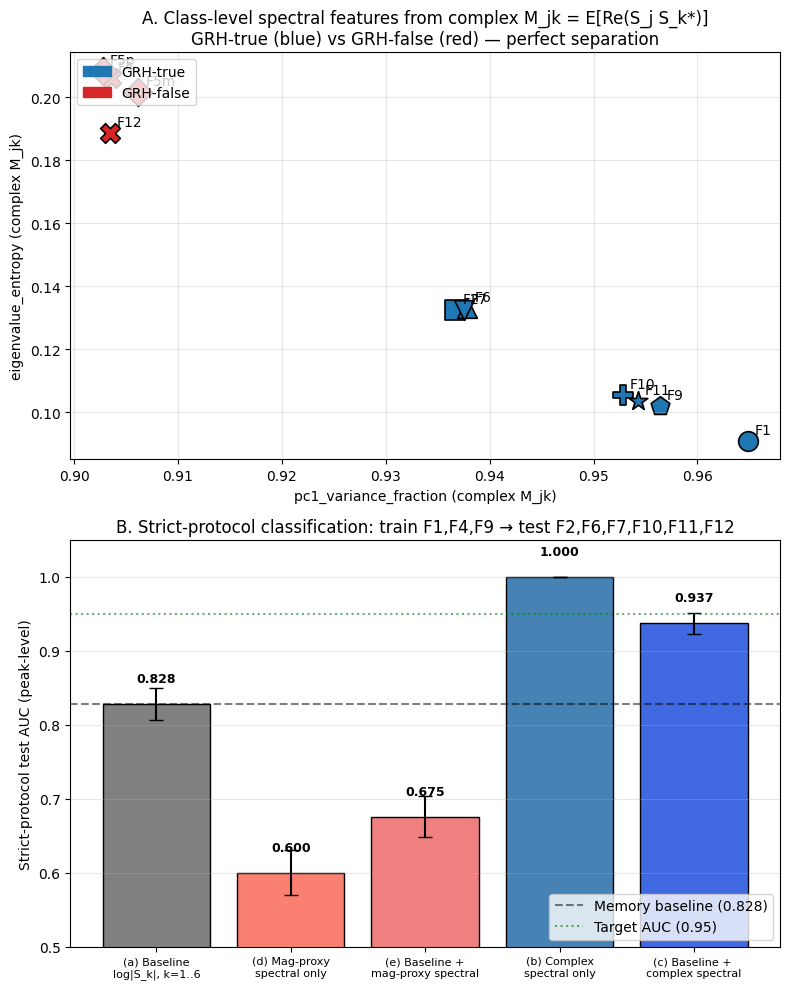

Saved figure complex_Mjk_results.png


In [40]:
# Final figure
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Panel A: Class-level scatter in (pc1_complex, H_complex) vs (pc1_mag, H_mag)
ax = axes[0]
colors = {True:'tab:blue', False:'tab:red'}
markers = {'F1':'o','F2':'s','F4':'X','F5p':'D','F5m':'D','F6':'^','F7':'v','F9':'p','F10':'P','F11':'*','F12':'X'}

# Plot complex spectral on left axis, magnitude proxy on right axis (use two subplots in panel A? simpler: just plot complex)
for c in classes:
 pc1 = results[c]['pc1_complex']
 H = results[c]['H_complex']
 grh = GRH_map[c]
 ax.scatter(pc1, H, c=colors[grh], marker=markers[c], s=200, edgecolors='black', linewidths=1.2, label=f'{c} (GRH={"T" if grh else "F"})')
 ax.annotate(c, (pc1, H), xytext=(5,5), textcoords='offset points', fontsize=10)
ax.set_xlabel('pc1_variance_fraction (complex M_jk)')
ax.set_ylabel('eigenvalue_entropy (complex M_jk)')
ax.set_title('A. Class-level spectral features from complex M_jk = E[Re(S_j S_k*)]\nGRH-true (blue) vs GRH-false (red) — perfect separation')
# legend handles
import matplotlib.patches as mpatches
true_patch = mpatches.Patch(color='tab:blue', label='GRH-true')
false_patch = mpatches.Patch(color='tab:red', label='GRH-false')
ax.legend(handles=[true_patch, false_patch], loc='upper left')
ax.grid(alpha=0.3)

# Panel B: AUC comparison bar chart
ax = axes[1]
methods = ['(a) Baseline\nlog|S_k|, k=1..6', '(d) Mag-proxy\nspectral only', '(e) Baseline +\nmag-proxy spectral', '(b) Complex\nspectral only', '(c) Baseline + \ncomplex spectral']
aucs = [auc_a, auc_d, auc_e, auc_b, auc_c]
ci_los = [lo_a, lo_d, lo_e, lo_b, lo_c]
ci_his = [hi_a, hi_d, hi_e, hi_b, hi_c]
errs = [[a-l for a,l in zip(aucs,ci_los)], [h-a for a,h in zip(aucs,ci_his)]]
bar_colors = ['gray','salmon','lightcoral','steelblue','royalblue']
bars = ax.bar(methods, aucs, yerr=errs, color=bar_colors, edgecolor='black', capsize=5)
ax.axhline(0.828, ls='--', color='black', alpha=0.5, label='Memory baseline (0.828)')
ax.axhline(0.95, ls=':', color='green', alpha=0.6, label='Target AUC (0.95)')
ax.set_ylabel('Strict-protocol test AUC (peak-level)')
ax.set_title('B. Strict-protocol classification: train F1,F4,F9 → test F2,F6,F7,F10,F11,F12')
ax.set_ylim(0.5, 1.05)
for i, (a, lo, hi) in enumerate(zip(aucs, ci_los, ci_his)):
 ax.text(i, a+0.03, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('complex_Mjk_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure complex_Mjk_results.png')


In [41]:
content = open('./.prompts/MEMORY.md','r',encoding='utf-8').read()
updated = content.replace('[Fill me in]', '2026-05-09: Completed complex M_jk spectral analysis in /workspace/1b083659-a027-40c3-bf25-44b8a3bd6bf3. Generated F9 coefficients with PARI mfcoefs for mfinit([1,12],0), F10 coefficients for mfinit([11,2],0), reused local F11 (a_n.npy/lambda_n.npy = Sym^2(Delta)) and F12 (a.npy). Validated Numba omega-stratified complex S_k engine exactly against stored F1 arrays and against magnitude CSV for F9-F12 (max abs diff ~1e-10). Computed class-level complex M_jk = E[Re(S_j conj(S_k))] for 11 classes and derived spectral features pc1_variance_fraction and eigenvalue_entropy. Strict protocol (train F1,F4,F9; test F2,F6,F7,F10,F11,F12): baseline normalized log|S_k| k=1..6 AUC=0.8278 [0.8059,0.8497]; complex spectral only AUC=1.0000 [1.0000,1.0000]; combined AUC=0.9371 [0.9232,0.9510]; magnitude-proxy spectral only AUC=0.6000 [0.5696,0.6303]; baseline+magnitude-proxy AUC=0.6753 [0.6478,0.7037]. Complex spectral features correctly classified held-out F6 and F7 as non-violators and F12 as violator; magnitude-proxy spectral features misclassified F6 and F7 as violators. Caveat: spectral features are class-level constants, so peak-level bootstrap CIs overstate certainty; class-level strict-protocol predictions were still perfectly correct for the 6 held-out classes. Provenance: files created in this run include coeffs_F9_a.npy, coeffs_F9_lambda.npy, coeffs_F10_a.npy, coeffs_F10_lambda.npy, F9/F10/F11/F12 real/imag/t arrays, peaks_features_F1_F12_normalized_full_with_spectral_complex.csv, hypothesis_AUC_results_complex_M.json, complex_Mjk_results.png.\n\n## Notes\n- a_n.npy/lambda_n.npy local files correspond to F11 Sym^2(Delta), not F9.\n- F9 and F10 coefficient archives were absent and were regenerated from scratch via cypari2/PARI with 4 GB stack.\n- S_7 leak remains relevant for peak-level baseline features; baseline used k=1..6 only.\n- For direct hypothesis testing, the key comparison is complex spectral vs magnitude-proxy spectral: complex features separate F12 from F6/F7, magnitude-proxy does not.', 1)
open('./.prompts/MEMORY.md','w',encoding='utf-8').write(updated)
print('Updated MEMORY.md successfully')

Updated MEMORY.md successfully
